In [1]:
import pandas as pd
import statsmodels.api as sm
from sklearn.metrics import roc_auc_score, classification_report


df = pd.read_csv("community_area_data.csv")

df.head()

,community_area_id,citation_pct,n_stops,community_area_name,drug_abuse,major_crime,public_crime,violent_crime,perceived_neighborhood_violence_rate,perceived_neighborhood_safety_rate,trust_in_law_enforcement,trust_in_law_enforcement_rate,trust_in_local_government,trust_in_local_government_rate,economic_diversity_index,hardship_index,median_household_income,limited_english_proficiency,population
0,1.0,0.528444,14291,ROGERS PARK,52.430941,1760.907198,495.0,298.203142,34.801957,73.174568,15800.0,29.978058,19500.0,36.961025,0.734804,52.924704,63293.406981,16.137010,54023.514047
1,2.0,0.743763,16313,WEST RIDGE,22.948027,1581.360787,339.0,266.247177,17.063957,67.910625,28900.0,57.228039,24500.0,48.332844,0.767896,76.071658,71334.903966,24.395617,78390.308219
2,3.0,0.541228,20435,UPTOWN,24.147636,1957.368091,373.0,294.201256,27.509064,77.214482,21000.0,43.905304,19500.0,40.778530,0.623804,35.406658,73109.526853,13.238442,54490.992635
3,4.0,0.960499,10253,LINCOLN SQUARE,26.977910,1276.689147,133.0,230.513409,11.108168,86.937593,14200.0,47.224830,17100.0,58.441246,0.636896,23.192702,91363.093539,12.868333,41565.112883
4,5.0,0.981344,4449,NORTH CENTER,12.453722,1215.406535,101.0,162.385518,13.120720,90.502351,17500.0,74.584491,11000.0,47.104718,0.433606,4.303042,147701.197916,3.040809,36047.308966


In [2]:
df.columns

Index(['community_area_id', 'citation_pct', 'n_stops', 'community_area_name',
       'drug_abuse', 'major_crime', 'public_crime', 'violent_crime',
       'perceived_neighborhood_violence_rate',
       'perceived_neighborhood_safety_rate', 'trust_in_law_enforcement',
       'trust_in_law_enforcement_rate', 'trust_in_local_government',
       'trust_in_local_government_rate', 'economic_diversity_index',
       'hardship_index', 'median_household_income',
       'limited_english_proficiency', 'population'],
      dtype='object')

In [3]:
import pandas as pd
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

community_df = df.copy()

community_df["n_citations"] = (
    community_df["citation_pct"] * community_df["n_stops"]
).round().astype(int)

community_df["n_non_citations"] = (
    community_df["n_stops"] - community_df["n_citations"]
)

community_df.head()

,community_area_id,citation_pct,n_stops,community_area_name,drug_abuse,major_crime,public_crime,violent_crime,perceived_neighborhood_violence_rate,perceived_neighborhood_safety_rate,...,trust_in_law_enforcement_rate,trust_in_local_government,trust_in_local_government_rate,economic_diversity_index,hardship_index,median_household_income,limited_english_proficiency,population,n_citations,n_non_citations
0,1.0,0.528444,14291,ROGERS PARK,52.430941,1760.907198,495.0,298.203142,34.801957,73.174568,...,29.978058,19500.0,36.961025,0.734804,52.924704,63293.406981,16.137010,54023.514047,7552,6739
1,2.0,0.743763,16313,WEST RIDGE,22.948027,1581.360787,339.0,266.247177,17.063957,67.910625,...,57.228039,24500.0,48.332844,0.767896,76.071658,71334.903966,24.395617,78390.308219,12133,4180
2,3.0,0.541228,20435,UPTOWN,24.147636,1957.368091,373.0,294.201256,27.509064,77.214482,...,43.905304,19500.0,40.778530,0.623804,35.406658,73109.526853,13.238442,54490.992635,11060,9375
3,4.0,0.960499,10253,LINCOLN SQUARE,26.977910,1276.689147,133.0,230.513409,11.108168,86.937593,...,47.224830,17100.0,58.441246,0.636896,23.192702,91363.093539,12.868333,41565.112883,9848,405
4,5.0,0.981344,4449,NORTH CENTER,12.453722,1215.406535,101.0,162.385518,13.120720,90.502351,...,74.584491,11000.0,47.104718,0.433606,4.303042,147701.197916,3.040809,36047.308966,4366,83


In [4]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt

from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.calibration import calibration_curve

final_vars = [
    #"violent_crime",
    "perceived_neighborhood_safety_rate",
    "trust_in_law_enforcement_rate",
    "economic_diversity_index",
    "median_household_income",
    "limited_english_proficiency",
    "population"
]

success_col = "n_citations"
failure_col = "n_non_citations"

X = community_df[final_vars].astype(float)
X = sm.add_constant(X)

y = community_df[[success_col, failure_col]].astype(float)

X_full = X.copy()
y_full = y.copy()

successes = y_full[success_col].values
failures = y_full[failure_col].values
trials = successes + failures
y_prop = successes / trials

def weighted_mae(y_true_prop, y_pred_prop, weights):
    return np.sum(weights * np.abs(y_true_prop - y_pred_prop)) / np.sum(weights)

def weighted_rmse(y_true_prop, y_pred_prop, weights):
    return np.sqrt(np.sum(weights * (y_true_prop - y_pred_prop) ** 2) / np.sum(weights))

def weighted_brier_score(y_true_prop, y_pred_prop, weights):
    return np.sum(weights * (y_true_prop - y_pred_prop) ** 2) / np.sum(weights)

def grouped_log_likelihood(successes, failures, pred_prob, eps=1e-15):
    p = np.clip(pred_prob, eps, 1 - eps)
    return np.sum(successes * np.log(p) + failures * np.log(1 - p))

def mcfadden_pseudo_r2(successes, failures, pred_prob):
    ll_model = grouped_log_likelihood(successes, failures, pred_prob)
    p_null = np.sum(successes) / (np.sum(successes) + np.sum(failures))
    ll_null = grouped_log_likelihood(
        successes, failures, np.repeat(p_null, len(successes))
    )
    return 1 - (ll_model / ll_null)

def expand_all(X_df, successes, failures):
    X_rows = []
    y_rows = []

    for i in range(len(X_df)):
        s = int(successes[i])
        f = int(failures[i])

        if s > 0:
            X_rows.append(pd.DataFrame([X_df.iloc[i].values] * s, columns=X_df.columns))
            y_rows.extend([1] * s)

        if f > 0:
            X_rows.append(pd.DataFrame([X_df.iloc[i].values] * f, columns=X_df.columns))
            y_rows.extend([0] * f)

    X_exp = pd.concat(X_rows, ignore_index=True)
    y_exp = np.array(y_rows)
    return X_exp, y_exp

X_expanded, y_expanded = expand_all(X_full, successes, failures)

models = {
    "No Penalty": {"alpha": 0.0, "L1_wt": 0.0},
    "L1": {"alpha": 0.01, "L1_wt": 1.0},
    "L2": {"alpha": 0.01, "L1_wt": 0.0},
    "Elastic Net": {"alpha": 0.01, "L1_wt": 0.5}
}

results = []
coef_rows = {}
pred_probs_grouped = {}
pred_probs_expanded = {}

for model_name, params in models.items():
    model = sm.GLM(y_full, X_full, family=sm.families.Binomial())

    if model_name == "No Penalty":
        result = model.fit()
    else:
        result = model.fit_regularized(alpha=params["alpha"], L1_wt=params["L1_wt"])

    p_grouped = result.predict(X_full)
    pred_probs_grouped[model_name] = p_grouped

    expanded_probs = []
    for i, p in enumerate(p_grouped):
        n_i = int(trials[i])
        expanded_probs.extend([p] * n_i)
    pred_probs_expanded[model_name] = np.array(expanded_probs)

    mae = weighted_mae(y_prop, p_grouped, trials)
    rmse = weighted_rmse(y_prop, p_grouped, trials)
    brier = weighted_brier_score(y_prop, p_grouped, trials)
    pseudo_r2 = mcfadden_pseudo_r2(successes, failures, p_grouped)
    auc = roc_auc_score(y_expanded, pred_probs_expanded[model_name])

    results.append({
        "Model": model_name,
        "Weighted MAE": mae,
        "Weighted RMSE": rmse,
        "Weighted Brier Score": brier,
        "McFadden Pseudo R^2": pseudo_r2,
        "ROC AUC": auc
    })

    coef_rows[model_name] = result.params

results_df = pd.DataFrame(results).sort_values("Weighted Brier Score").reset_index(drop=True)
coef_df = pd.DataFrame(coef_rows).T.reset_index().rename(columns={"index": "Model"})

print("MODEL COMPARISON")
display(results_df)

print("\nCOEFFICIENTS")
display(coef_df)

/Users/janak/Library/Python/3.9/lib/python/site-packages/statsmodels/genmod/generalized_linear_model.py:1464: UserWarning: Elastic net fitting did not converge
  warnings.warn("Elastic net fitting did not converge")
/Users/janak/Library/Python/3.9/lib/python/site-packages/statsmodels/genmod/families/links.py:198: RuntimeWarning: overflow encountered in exp
  t = np.exp(-z)
/Users/janak/Library/Python/3.9/lib/python/site-packages/statsmodels/genmod/families/family.py:1056: RuntimeWarning: divide by zero encountered in log
  special.gammaln(n - y + 1) + y * np.log(mu / (1 - mu + 1e-20)) +
/Users/janak/Library/Python/3.9/lib/python/site-packages/statsmodels/genmod/families/links.py:198: RuntimeWarning: overflow encountered in exp
  t = np.exp(-z)
/Users/janak/Library/Python/3.9/lib/python/site-packages/statsmodels/genmod/families/family.py:1056: RuntimeWarning: divide by zero encountered in log
  special.gammaln(n - y + 1) + y * np.log(mu / (1 - mu + 1e-20)) +
/Users/janak/Library/Python/

MODEL COMPARISON


/Users/janak/Library/Python/3.9/lib/python/site-packages/statsmodels/genmod/generalized_linear_model.py:1464: UserWarning: Elastic net fitting did not converge
  warnings.warn("Elastic net fitting did not converge")


,Model,Weighted MAE,Weighted RMSE,Weighted Brier Score,McFadden Pseudo R^2,ROC AUC
0,No Penalty,0.151543,0.200589,0.040236,0.085553,0.709871
1,L1,0.153024,0.200789,0.040316,0.084279,0.708617
2,Elastic Net,0.153024,0.200789,0.040316,0.084279,0.708617
3,L2,0.281858,0.310625,0.096488,-0.108071,0.500000



COEFFICIENTS


,Model,const,perceived_neighborhood_safety_rate,trust_in_law_enforcement_rate,economic_diversity_index,median_household_income,limited_english_proficiency,population
0,No Penalty,-2.165012,0.024632,-0.025424,1.666232,-0.000010,0.050659,0.00001
1,L1,-1.568187,0.015447,-0.025080,1.302532,-0.000008,0.052517,0.00001
2,L2,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
3,Elastic Net,-1.568167,0.015447,-0.025080,1.302521,-0.000008,0.052517,0.00001


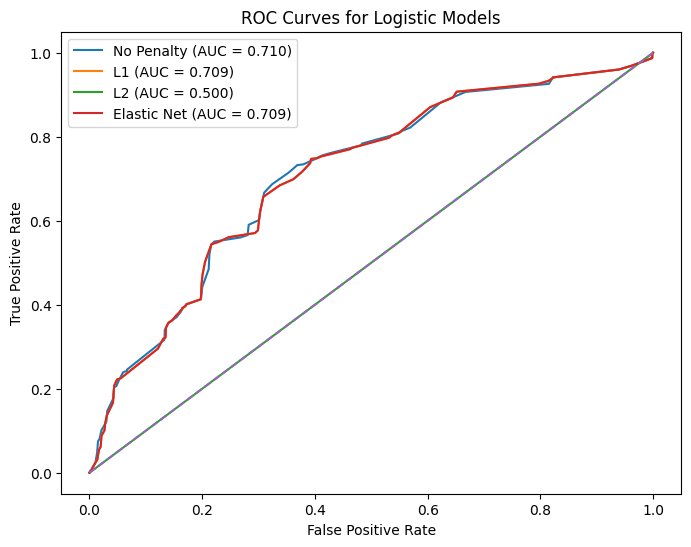

In [5]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

plt.figure(figsize=(8, 6))

for model_name in pred_probs_expanded:
    fpr, tpr, _ = roc_curve(y_expanded, pred_probs_expanded[model_name])
    auc = roc_auc_score(y_expanded, pred_probs_expanded[model_name])
    plt.plot(fpr, tpr, label=f"{model_name} (AUC = {auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--")  # random baseline
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for Logistic Models")
plt.legend()
plt.show()

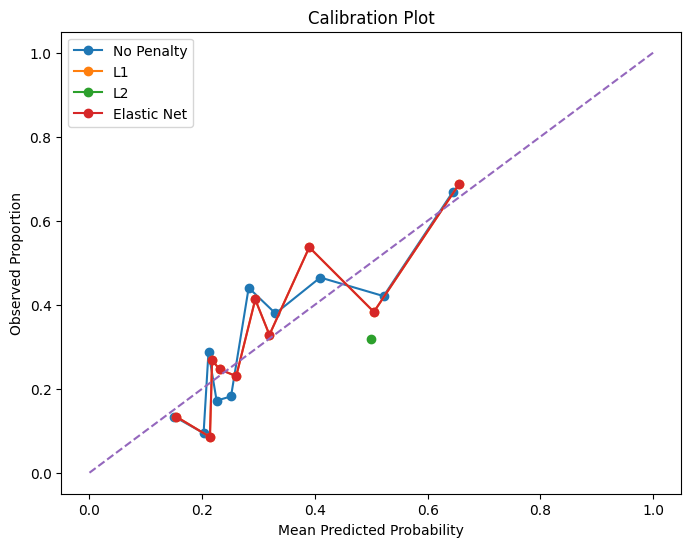

In [6]:
from sklearn.calibration import calibration_curve

plt.figure(figsize=(8, 6))

for model_name in pred_probs_expanded:
    frac_pos, mean_pred = calibration_curve(
        y_expanded,
        pred_probs_expanded[model_name],
        n_bins=10,
        strategy="quantile"
    )
    plt.plot(mean_pred, frac_pos, marker="o", label=model_name)

plt.plot([0, 1], [0, 1], linestyle="--")  # perfect calibration line
plt.xlabel("Mean Predicted Probability")
plt.ylabel("Observed Proportion")
plt.title("Calibration Plot")
plt.legend()
plt.show()

# Interpretation

In [7]:
import pandas as pd
import numpy as np
import statsmodels.api as sm

# final unregularized model on full data
final_model = sm.GLM(y_full, X_full, family=sm.families.Binomial()).fit()

print(final_model.summary())

                         Generalized Linear Model Regression Results                          
Dep. Variable:     ['n_citations', 'n_non_citations']   No. Observations:                   76
Model:                                            GLM   Df Residuals:                       69
Model Family:                                Binomial   Df Model:                            6
Link Function:                                  Logit   Scale:                          1.0000
Method:                                          IRLS   Log-Likelihood:            -1.8611e+05
Date:                                Thu, 16 Apr 2026   Deviance:                   3.7151e+05
Time:                                        13:30:23   Pearson chi2:                 3.82e+05
No. Iterations:                                     5   Pseudo R-squ. (CS):              1.000
Covariance Type:                            nonrobust                                         
                                         coef    s

In [8]:
# coefficient interpretation table
coef_table = pd.DataFrame({
    "Variable": final_model.params.index,
    "Coefficient": final_model.params.values,
    "Odds Ratio": np.exp(final_model.params.values),
    "P-value": final_model.pvalues.values,
    "CI Lower": final_model.conf_int()[0].values,
    "CI Upper": final_model.conf_int()[1].values
})

coef_table["OR CI Lower"] = np.exp(coef_table["CI Lower"])
coef_table["OR CI Upper"] = np.exp(coef_table["CI Upper"])

display(coef_table)

,Variable,Coefficient,Odds Ratio,P-value,CI Lower,CI Upper,OR CI Lower,OR CI Upper
0,const,-2.165012,0.114749,0.0,-2.210878,-2.119146,0.109604,0.120134
1,perceived_neighborhood_safety_rate,0.024632,1.024938,0.0,0.024262,0.025002,1.024559,1.025317
2,trust_in_law_enforcement_rate,-0.025424,0.974896,0.0,-0.025917,-0.024932,0.974416,0.975377
3,economic_diversity_index,1.666232,5.292191,0.0,1.618252,1.714213,5.044265,5.552302
4,median_household_income,-0.000010,0.999990,0.0,-0.000010,-0.000010,0.999990,0.999990
5,limited_english_proficiency,0.050659,1.051964,0.0,0.050236,0.051081,1.051520,1.052409
6,population,0.000010,1.000010,0.0,0.000010,0.000011,1.000010,1.000011


In [9]:
from sklearn.preprocessing import StandardScaler

# standardize predictors only, not the response
X_scaled_only = community_df[final_vars].astype(float).copy()

scaler = StandardScaler()
X_scaled_array = scaler.fit_transform(X_scaled_only)

X_scaled_df = pd.DataFrame(X_scaled_array, columns=final_vars, index=community_df.index)
X_scaled_df = sm.add_constant(X_scaled_df)

# same grouped response
y_scaled = community_df[[success_col, failure_col]].astype(float)

# standardized no-penalty model
final_model_std = sm.GLM(y_scaled, X_scaled_df, family=sm.families.Binomial()).fit()

print(final_model_std.summary())

                         Generalized Linear Model Regression Results                          
Dep. Variable:     ['n_citations', 'n_non_citations']   No. Observations:                   76
Model:                                            GLM   Df Residuals:                       69
Model Family:                                Binomial   Df Model:                            6
Link Function:                                  Logit   Scale:                          1.0000
Method:                                          IRLS   Log-Likelihood:            -1.8611e+05
Date:                                Thu, 16 Apr 2026   Deviance:                   3.7151e+05
Time:                                        13:30:23   Pearson chi2:                 3.82e+05
No. Iterations:                                     5   Pseudo R-squ. (CS):              1.000
Covariance Type:                            nonrobust                                         
                                         coef    s

In [10]:
std_coef_table = pd.DataFrame({
    "Variable": final_model_std.params.index,
    "Standardized Coefficient": final_model_std.params.values,
    "P-value": final_model_std.pvalues.values
})

std_coef_table = std_coef_table[std_coef_table["Variable"] != "const"]
std_coef_table["Abs Std Coef"] = std_coef_table["Standardized Coefficient"].abs()
std_coef_table = std_coef_table.sort_values("Abs Std Coef", ascending=False)

display(std_coef_table)

,Variable,Standardized Coefficient,P-value,Abs Std Coef
5,limited_english_proficiency,0.632267,0.0,0.632267
1,perceived_neighborhood_safety_rate,0.402572,0.0,0.402572
4,median_household_income,-0.308708,0.0,0.308708
2,trust_in_law_enforcement_rate,-0.301161,0.0,0.301161
6,population,0.240962,0.0,0.240962
3,economic_diversity_index,0.203889,0.0,0.203889


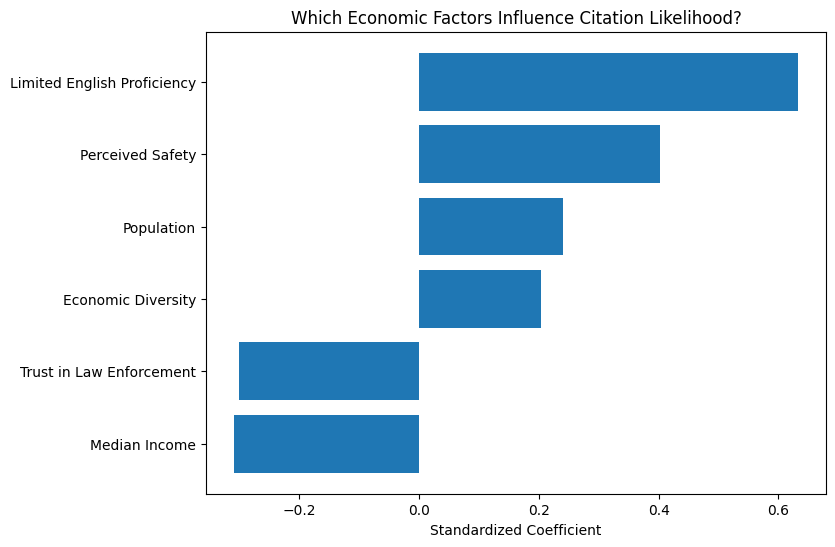

In [13]:
plot_df = std_coef_table.sort_values("Standardized Coefficient")

# rename variables
name_map = {
    "limited_english_proficiency": "Limited English Proficiency",
    "perceived_neighborhood_safety_rate": "Perceived Safety",
    "population": "Population",
    "economic_diversity_index": "Economic Diversity",
    "trust_in_law_enforcement_rate": "Trust in Law Enforcement",
    "median_household_income": "Median Income"
}

plot_df["Variable"] = plot_df["Variable"].map(name_map)

plt.figure(figsize=(8, 6))
plt.barh(plot_df["Variable"], plot_df["Standardized Coefficient"])
plt.xlabel("Standardized Coefficient")
plt.ylabel("")
plt.title("Which Economic Factors Influence Citation Likelihood?")
plt.show()

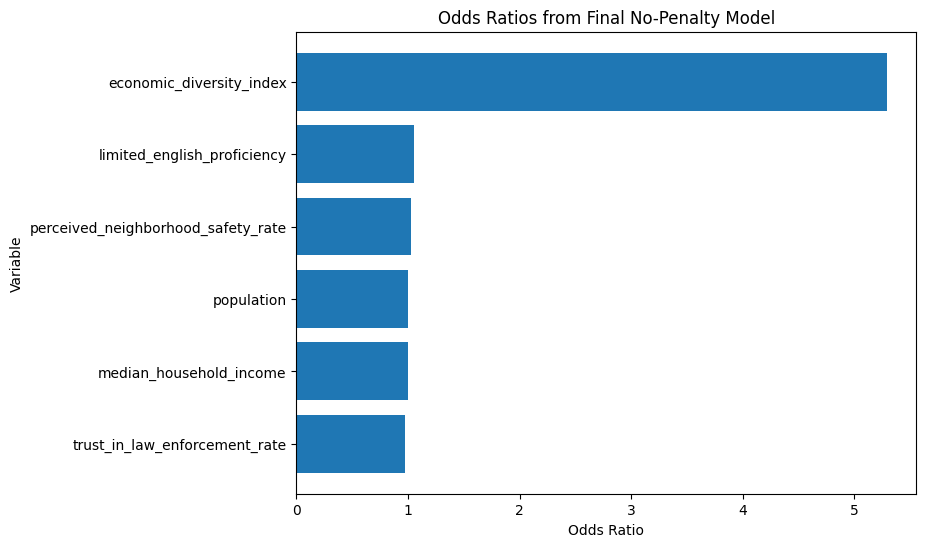

In [12]:
or_plot_df = coef_table[coef_table["Variable"] != "const"].copy()
or_plot_df = or_plot_df.sort_values("Odds Ratio")

plt.figure(figsize=(8, 6))
plt.barh(or_plot_df["Variable"], or_plot_df["Odds Ratio"])
plt.xlabel("Odds Ratio")
plt.ylabel("Variable")
plt.title("Odds Ratios from Final No-Penalty Model")
plt.show()